*Parts of this notebook are based on notebooks provided with the book: [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas; the original content is available [on GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).*

In [64]:
import numpy as np

# NumPy Exercises:  Boolean masks and aggregations

### Exercise 1

Write a command that replaces all NaN values with 0 in the following array.  Use [np.isnan](https://numpy.org/doc/stable/reference/generated/numpy.isnan.html) with Boolean indexing.

In [65]:
a = np.array([1,2,3,np.nan,5,6,7,np.nan])

In [66]:
# replace all occurrences of NaN with 0
# use np.isnan# returns a boolean array where True indicates the position of NaN
a[np.isnan(a)] = 0
a



array([1., 2., 3., 0., 5., 6., 7., 0.])

Sometimes we just want to get rid of NaN values.  Write a command that creates a new array that contains only the non-NaN values from the array.

In [67]:
a = np.array([1,2,3,np.nan,5,6,7,np.nan])
# new array that contains only the non-NaN values
a[~np.isnan(a)]




array([1., 2., 3., 5., 6., 7.])

### Exercise 2

* Create an array of size $5 \times 6$ with random values between 0 and 1 and find the minimum and maximum values in the entire array, and in each column / row.

In [68]:
from numpy.random import default_rng

In [69]:
rng = default_rng()
b = rng.random(size=(5,6))
np.min(b)

np.float64(0.0043877002022228995)

In [70]:
np.min(b, axis = 0)

array([0.01348202, 0.0043877 , 0.08675506, 0.27883375, 0.07564717,
       0.14970664])

In [71]:
np.min(b, axis = 1)

array([0.0043877 , 0.01348202, 0.07564717, 0.08675506, 0.17852267])

In [72]:
np.max(b)

np.float64(0.9959415619895766)

In [73]:
np.max(b, axis=0)

array([0.82695782, 0.75369536, 0.7688973 , 0.99594156, 0.86892121,
       0.77337976])

In [74]:
np.max(b, axis = 1)

array([0.7688973 , 0.77337976, 0.99594156, 0.86892121, 0.79032525])

### Exercise 3

As another example of using NumPy for machine learning computations, we will compute the accuracy of a classifier.  Here you are given vectors $y$ and $\hat{y}$, where $y=(y_1,\ldots,y_N)$ are the given labels and $\hat{y} = (\hat{y}_1,\ldots,\hat{y}_N)$ are the predicted labels.  Both $y$ and $\hat{y}$ are vectors of integers.

Mathematically accuracy is expressed as:
$$
\mathrm{accuracy} = \frac{1}{N}\sum_{i=1}^N \left[\hat{y}_i = y_i\right].
$$
Here the notation $[\mathrm{condition}]$ is the [Iverson bracket](https://en.wikipedia.org/wiki/Iverson_bracket), which is equal to 1 if the condition is true, and 0 otherwise.  What this does, is count the fraction of times $y_i$ is equal to $\hat{y}_i$.
Also note that the equality sign in this formula corresponds to the programming `==` operator.

In [75]:
y = np.array([0, 1, 1, 1, 0])
y_pred = np.array([1, 0, 1, 1, 0])
accuracy = np.sum(y == y_pred) / len(y)
accuracy


np.float64(0.6)

For your reference here is a pure Python implementation:

In [76]:
accuracy = sum([ y[i]==y_pred[i] for i in range(len(y)) ]) / len(y)
accuracy

np.float64(0.6)

### Exercise 4:  Rainfall in Seattle

Contrary to popular belief, Seattle is not as rainy as you would think.  To see what the data says, we will load a dataset containing data on one year's rainfall.  Like many of the datasets we will look at in this course, the data is in a CSV file.  NumPy provides us a method for reading such files using [np.genfromtxt](https://numpy.org/doc/stable/reference/generated/numpy.genfromtxt.html).
The information we are interested in is contained in the fourth column of the dataset, so we will read only that column.  Another nice feature of `genfromtxt`, is that the file doesn't have to be stored on your machine, and can be read directly from a CSV file stored somewhere on the internet.

In [77]:
# genfromtxt reads delimited files
# the default delimiter is space, so we need to explicitly tell it to use
# comma as the delimiter
# the precipitation data is in the fourth column of the CSV file
# the file has a header row which we want to skip

url = 'https://github.com/jakevdp/PythonDataScienceHandbook/raw/master/notebooks_v1/data/Seattle2014.csv'
rainfall = np.genfromtxt(url, delimiter=',', skip_header=1, usecols=3)
rainfall.shape, rainfall.dtype

((365,), dtype('float64'))

The array contains 365 values, giving daily rainfall in mm from January 1 to December 31, 2014.

As a first quick visualization, let's look at the histogram of rainfall using Matplotlib:

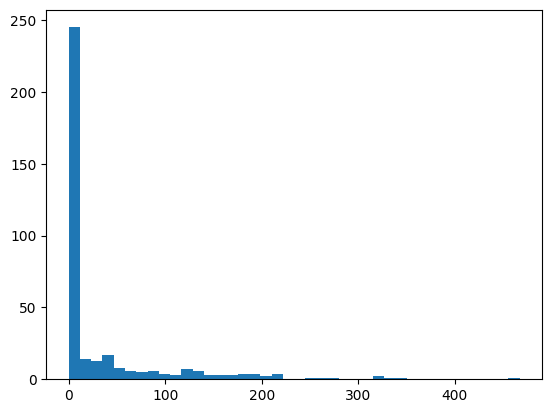

In [78]:
import matplotlib.pyplot as plt
plt.hist(rainfall,40);

This histogram gives us a general idea of what the data looks like: despite its reputation, the vast majority of days in Seattle saw zero or close to zero rainfall in 2014. In the following exercises you will answer more detailed questions about the data.

In the following exercises use array Boolean operations (and refrain from using for loops!) to determine the following:

* To confirm our observation from the histogram, how many days had zero rainfall?

In [79]:
np.sum(rainfall == 0)

np.int64(215)

* How many days had rainfall of between 10mm and 200mm?  (FYI there are 254 mm in an inch). 

In [80]:
np.sum((rainfall >= 10) & (rainfall <= 200))

np.int64(109)

Wasn't entirely sure if I had to make the bounds inclusive or exclusive, but decided that inclusive was likely what you wanted. 

* How many days with rain had strictly less than 10mm of rain?

In [81]:
np.sum((rainfall > 0) & (rainfall < 10))

np.int64(27)

* What was the average precipitation on rainy days?  (Use `np.mean` to compute the average).

In [82]:
np.mean(rainfall[rainfall > 0])

np.float64(82.18666666666667)

* What was the average precipitation on summer rainy days (i.e. summer days that had rain)?  We'll count summer as going from June 21st which is the 172nd day of the year until (and including), day 262 of the year.  

In [83]:
summer = rainfall[172 : 263]
np.mean(summer[summer > 0])

np.float64(52.5)